Large Language Models (LLMs) are often associated with cloud APIs and external services, but it is increasingly possible to run powerful models locally. This opens up new possibilities for privacy-preserving workflows, faster experimentation, and better control over model behavior.

In this tutorial, we explore how to use LangChain together with Ollama to interact with a locally running LLM. Rather than focusing on theory, the goal is to demonstrate practical patterns that can be reused in real-world applications.

We will walk through a series of progressively useful tasks: starting with simple question-answering, moving to text summarization and sentiment analysis, and finally exploring creative text generation. Each example highlights how prompt design and chaining can be used to structure interactions with the model.

By the end of this tutorial, you will have a working understanding of how to build lightweight, local LLM pipelines for common natural language processing tasks.

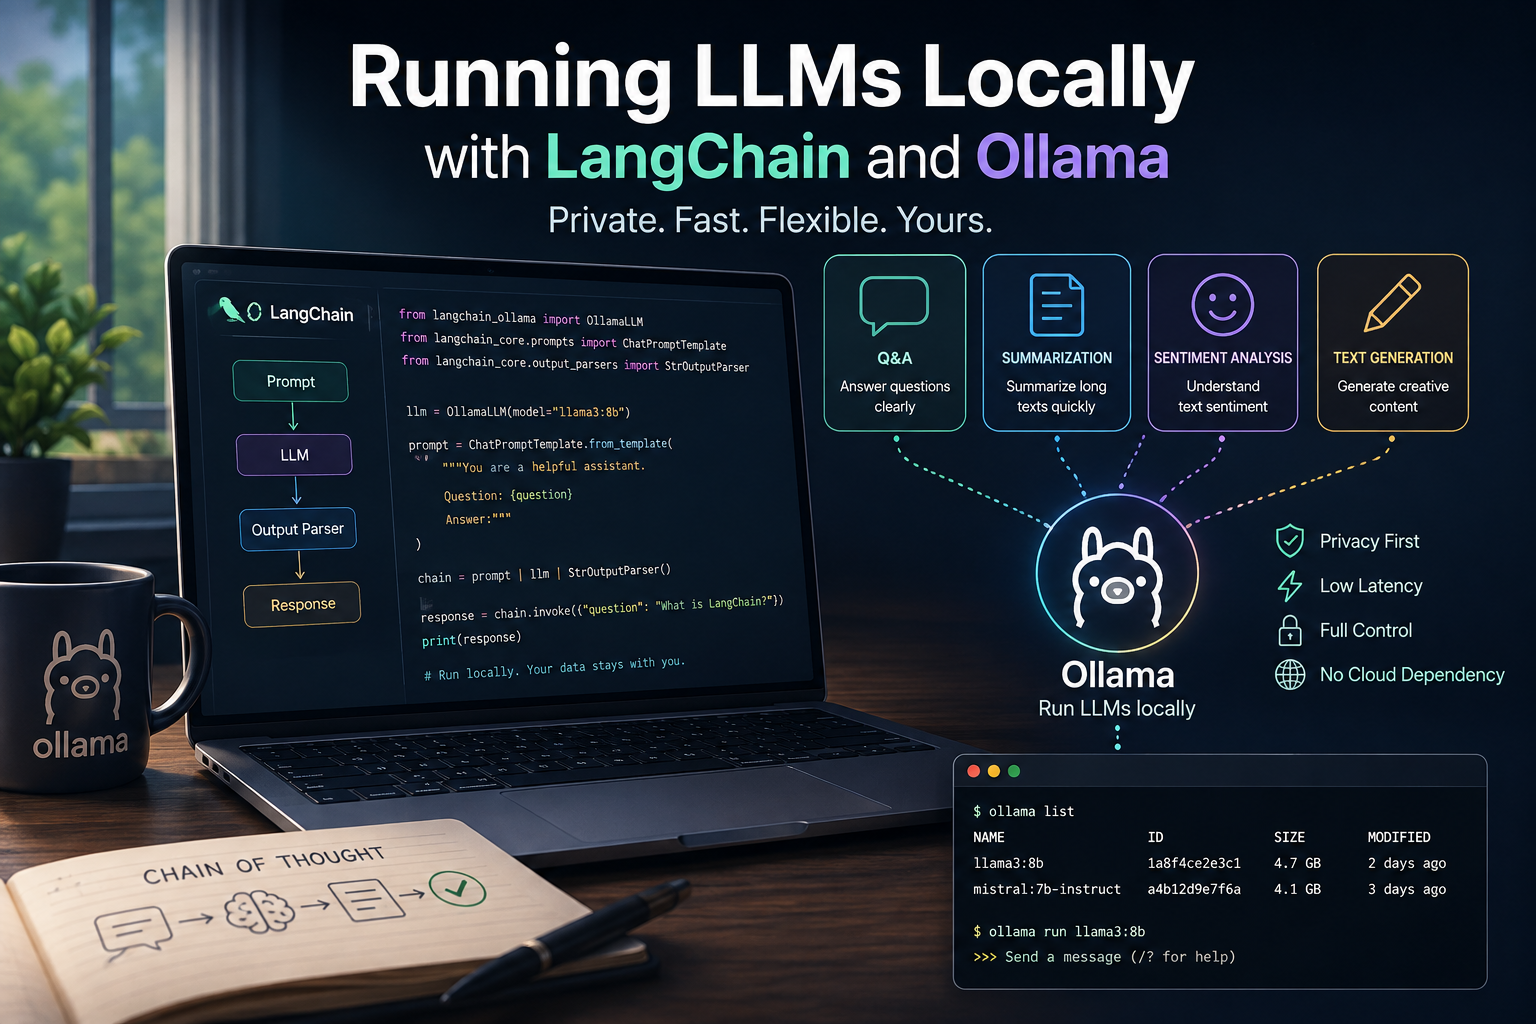

In [1]:
from IPython.display import Image, display

display(Image(filename="Image.png"))

# Simple Chat / Q&A

In [2]:
#pip install -U langchain-ollama

In [3]:
#pip uninstall langchain langchain-core langchain-community -y
#pip install langchain langchain-core langchain-community langchain-ollama

In [7]:
from langchain_ollama import OllamaLLM
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate(
    template="Explain overfitting in machine learning in one concise paragraph.",
    input_variables=[]
)

llm = OllamaLLM(model="llama3.2")
chain = prompt | llm

print(chain.invoke({}))

Overfitting is a phenomenon in machine learning where a model becomes too complex and learns the noise and random fluctuations in the training data, rather than generalizing to unseen data. As a result, the model performs exceptionally well on the training set but poorly on new, unseen data, leading to poor performance on test sets or real-world applications. This occurs when the model is overparameterized (too many parameters) or has too many complex features that don't actually contribute to the underlying relationship being modeled, causing it to memorize the specific patterns in the training data rather than discovering a more generalizable representation of the underlying phenomenon.


# Summarizing text 

In [8]:
from langchain_ollama import OllamaLLM
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate(
    template="Summarize the following text in 3 bullet points:\n\n{text}",
    input_variables=["text"]
)

llm = OllamaLLM(model="llama3.2")
chain = prompt | llm

article = """Artificial intelligence is rapidly changing...
...businesses and individuals are adopting it across industries."""

print(chain.invoke({"text": article}))

Here is a summary of the text in 3 bullet points:

• Artificial intelligence (AI) is evolving quickly.
• Businesses and individuals are increasingly adopting AI technology.
• AI is being applied across various industries, transforming them as part of this rapid adoption.


# Sentiment Analysis

In [ ]:
from langchain_ollama import OllamaLLM
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate(
    template="Classify the sentiment as Positive, Negative, or Neutral:\n\n{text}",
    input_variables=["text"]
)

llm = OllamaLLM(model="llama2", temperature=0)
chain = prompt | llm

for t in [
    "I love this new feature!",
    "The app keeps crashing!",
    "It's fine, nothing special."
]:
    print(f"{t} → {chain.invoke({'text': t}).strip()}")

# Creative generation 

In [ ]:
print(llm.invoke("Write a short bedtime story about a curious data scientist who teaches AI to dream."))